In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulator = AerSimulator()
shots = 1000

bell_circuits = {}
bell_results = {}

In [2]:
# 1. Phi plus (Start: |00>)
qc_phi_plus = QuantumCircuit(2, 2)
qc_phi_plus.h(0)
qc_phi_plus.cx(0, 1)
qc_phi_plus.measure([0, 1], [0, 1])
bell_circuits['Phi+'] = qc_phi_plus

# 2. Phi minus (Start: |10>)
qc_phi_minus = QuantumCircuit(2, 2)
qc_phi_minus.x(0)
qc_phi_minus.h(0)
qc_phi_minus.cx(0, 1)
qc_phi_minus.measure([0, 1], [0, 1])
bell_circuits['Phi-'] = qc_phi_minus

# 3. Psi plus (Start: |01>)
qc_psi_plus = QuantumCircuit(2, 2)
qc_psi_plus.x(1)
qc_psi_plus.h(0)
qc_psi_plus.cx(0, 1)
qc_psi_plus.measure([0, 1], [0, 1])
bell_circuits['Psi+'] = qc_psi_plus

# 4. Psi minus (Start: |11>)
qc_psi_minus = QuantumCircuit(2, 2)
qc_psi_minus.x(0)
qc_psi_minus.x(1)
qc_psi_minus.h(0)
qc_psi_minus.cx(0, 1)
qc_psi_minus.measure([0, 1], [0, 1])
bell_circuits['Psi-'] = qc_psi_minus

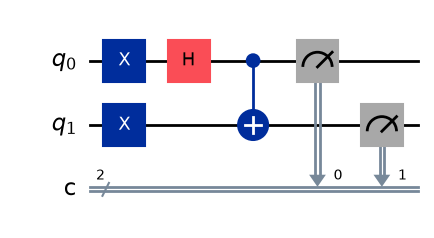

In [7]:
bell_circuits['Phi+'].draw('mpl', filename='Images/bell_phi_plus.png')
bell_circuits['Phi-'].draw('mpl', filename='Images/bell_phi_minus.png')
bell_circuits['Psi+'].draw('mpl', filename='Images/bell_psi_plus.png')
bell_circuits['Psi-'].draw('mpl', filename='Images/bell_psi_minus.png')

In [4]:
for name, circuit in bell_circuits.items():
    job = simulator.run(circuit, shots=shots)
    results = job.result()
    bell_results[name] = results.get_counts(circuit)

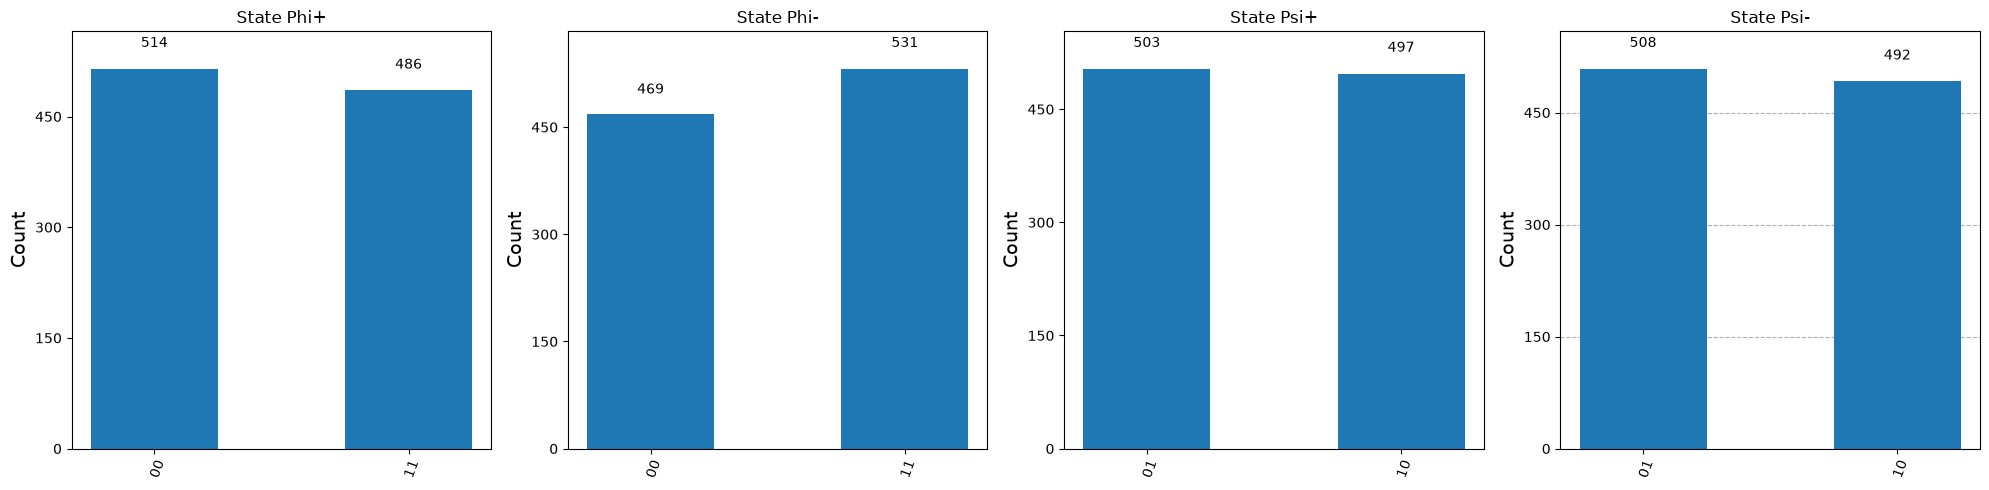

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, counts) in zip(axes, bell_results.items()):
    plot_histogram(counts, ax=ax)
    ax.set_title(f"State {name}")
    
plt.tight_layout()
plt.show()